# Class weight tuning

Use the preprocessed cross-validation folds and optimized hyperparameters from notebook `03-data-preprocessing` to find the optimal class weighting for the model. Balanced accuracy is used as the optimization metric, and a final balanced accuracy estimate is reported using the same CV folds.

## 1. Notebook setup

### 1.1. Imports

In [1]:
# Standard library
import pickle

# Third party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Internal
from helper_functions.data_preprocessing import encode_label

### 1.2. Configuration

In [2]:
RUN_CLASS_WEIGHT_OPTIMIZATION = True
RUN_FINE_SCAN                 = True
RUN_PERFORMANCE_ESTIMATION    = True

# Input artifacts (outputs from notebook 03)
CV_FOLD_DATASET         = '../data/tmp/03-preprocessed-cv-folds.pkl'
WINNING_HYPERPARAMETERS = '../data/results/03-winning-hyperparameters.pkl'
FINAL_TRAINING_DATA     = '../data/tmp/03-preprocessed-train-data.csv'
FINAL_TESTING_DATA      = '../data/tmp/03-preprocessed-test-data.csv'

# Outputs
CLASS_WEIGHT_SCORES      = '../data/results/04-class-weight-scores.pkl'
FINE_CLASS_WEIGHT_SCORES = '../data/results/04-fine-class-weight-scores.pkl'
WINNING_CLASS_WEIGHTS    = '../data/results/04-winning-class-weights.pkl'
PERFORMANCE_SCORES       = '../data/results/04-performance-scores.pkl'

## 2. Load artifacts from notebook 03

In [3]:
# CV folds - already preprocessed fold-by-fold (no leakage)
with open(CV_FOLD_DATASET, 'rb') as f:
    cv_folds = pd.read_pickle(f)

# Optimized model hyperparameters
with open(WINNING_HYPERPARAMETERS, 'rb') as f:
    winning_params = pickle.load(f)

n_folds = len(cv_folds)

print(f'Loaded {n_folds} CV folds')
print(f'Winning hyperparameters: {winning_params}')

Loaded 10 CV folds
Winning hyperparameters: {'max_depth': 7, 'learning_rate': np.float64(0.05), 'max_iter': 200, 'max_features': np.float64(0.8)}


In [4]:
# Recreate label encoder from raw data - needed to inverse-transform predictions for submission
raw_train = pd.read_csv(
    'https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/'
    'refs/heads/main/data/student-health-risk-train.csv'
)
_, label_encoder = encode_label(raw_train['health_condition'])
print(f'Classes: {label_encoder.classes_}')

Classes: ['at-risk' 'fit' 'unhealthy']


## 3. Class weight optimization

Sweep a scale factor applied to the perfectly balanced class weights:

- `scale = 0.0` - uniform weights (no class weighting)
- `scale = 1.0` - fully balanced (`class_weight='balanced'`)
- `scale > 1.0` - over-corrected (minority classes weighted more heavily)

Per-class weight at a given scale factor: `w_i = 1 + (w_balanced_i - 1) * scale`

### 3.1. Define weight configurations

In [5]:
# Scale factors to sweep
scale_factors = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 4.0]

print(f'Sweeping {len(scale_factors)} scale factors')
print('Per-class weights will be computed from each fold\'s training data only')


Sweeping 10 scale factors
Per-class weights will be computed from each fold's training data only


### 3.2. Optimization run

In [6]:
%%time

if RUN_CLASS_WEIGHT_OPTIMIZATION:

    scores = {
        'scale_factor': [],
        'balanced_accuracy': []
    }

    for sf in scale_factors:
        print(f'Scale factor {sf:.2f}... ', end='')
        fold_scores = []

        for fold in cv_folds:
            # Compute balanced weights from this fold's training data only (no leakage)
            fold_classes  = np.unique(fold['y_train'])
            fold_balanced = compute_class_weight('balanced', classes=fold_classes, y=fold['y_train'])
            fold_weights  = {int(cls): float(1.0 + (w - 1.0) * sf)
                             for cls, w in zip(fold_classes, fold_balanced)}

            model = HistGradientBoostingClassifier(
                **winning_params,
                class_weight=fold_weights,
                random_state=315
            )
            model.fit(fold['x_train'], fold['y_train'])

            y_pred = model.predict(fold['x_validation'])
            score  = balanced_accuracy_score(fold['y_validation'], y_pred)
            fold_scores.append(score)

        scores['scale_factor'].extend([sf] * n_folds)
        scores['balanced_accuracy'].extend(fold_scores)
        print(f'median balanced accuracy = {np.median(fold_scores):.4f} +/- {np.std(fold_scores):.4f}')

    with open(CLASS_WEIGHT_SCORES, 'wb') as f:
        pickle.dump(scores, f)

else:
    with open(CLASS_WEIGHT_SCORES, 'rb') as f:
        scores = pickle.load(f)

# Select best by highest median balanced accuracy
scores_df = pd.DataFrame(scores)
median_scores = scores_df.groupby('scale_factor')['balanced_accuracy'].median().sort_values(ascending=False)

best_scale_factor = median_scores.index[0]
best_ba           = median_scores.iloc[0]

# Compute final class weights from ALL training data. This is for the final
# model only (trained on the full dataset), not used in CV evaluation above.
y_all = np.concatenate([fold['y_train'] for fold in cv_folds])
classes = np.unique(y_all)
balanced_weights = compute_class_weight('balanced', classes=classes, y=y_all)

best_class_weights = {
    int(cls): float(1.0 + (w - 1.0) * best_scale_factor)
    for cls, w in zip(classes, balanced_weights)
}

with open(WINNING_CLASS_WEIGHTS, 'wb') as f:
    pickle.dump(best_class_weights, f)

print(f'\nBest scale factor:              {best_scale_factor}')
print(f'Median balanced accuracy:       {best_ba:.4f}')
print(f'Class weights (final model):    {best_class_weights}')
print()


Scale factor 0.00... median balanced accuracy = 0.8756 +/- 0.0026
Scale factor 0.25... median balanced accuracy = 0.9272 +/- 0.0014
Scale factor 0.50... median balanced accuracy = 0.9443 +/- 0.0009
Scale factor 0.75... median balanced accuracy = 0.9483 +/- 0.0009
Scale factor 1.00... median balanced accuracy = 0.9496 +/- 0.0011
Scale factor 1.25... median balanced accuracy = 0.9492 +/- 0.0012
Scale factor 1.50... median balanced accuracy = 0.9426 +/- 0.0013
Scale factor 2.00... median balanced accuracy = 0.5920 +/- 0.0734
Scale factor 3.00... median balanced accuracy = 0.5007 +/- 0.0437
Scale factor 4.00... median balanced accuracy = 0.4817 +/- 0.0249

Best scale factor:              1.0
Median balanced accuracy:       0.9496
Class weights (final model):    {0: 0.3881951956563685, 1: 5.779195873007898, 2: 3.9849860254544613}

CPU times: user 3h 20min 12s, sys: 53.4 s, total: 3h 21min 6s
Wall time: 18min 46s


### 3.3. Results

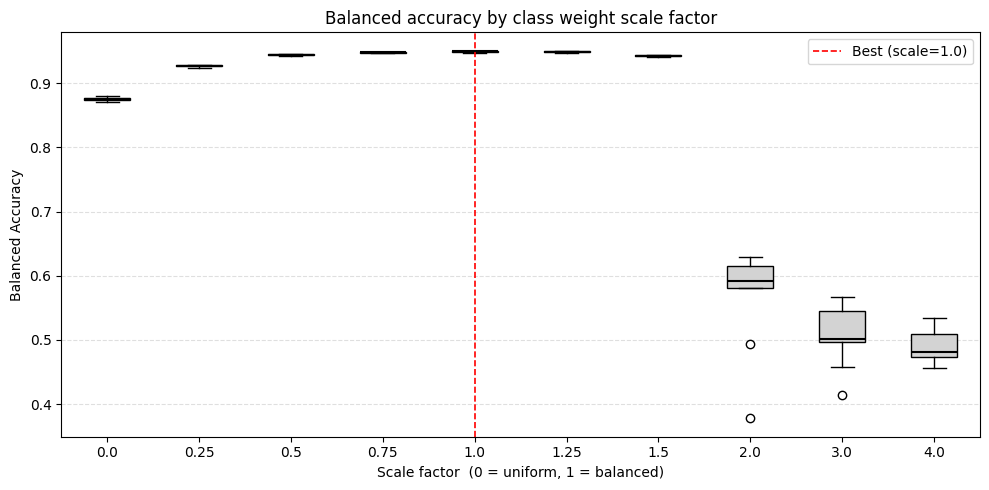

In [7]:
sorted_sfs = sorted(scores_df['scale_factor'].unique())
plot_data  = [scores_df.loc[scores_df['scale_factor'] == sf, 'balanced_accuracy'].values for sf in sorted_sfs]
labels     = [str(sf) for sf in sorted_sfs]
best_idx   = sorted_sfs.index(best_scale_factor) + 1  # 1-indexed for matplotlib

plt.figure(figsize=(10, 5))
plt.boxplot(
    plot_data,
    tick_labels=labels,
    patch_artist=True,
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)
plt.axvline(
    x=best_idx,
    color='red',
    linestyle='--',
    linewidth=1.2,
    label=f'Best (scale={best_scale_factor})'
)
plt.title('Balanced accuracy by class weight scale factor')
plt.xlabel('Scale factor  (0 = uniform, 1 = balanced)')
plt.ylabel('Balanced Accuracy')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 3.4. Fine scan (0.80 – 1.20)

Zoom in around the coarse winner with a step of 0.02 to nail down the optimal scale factor before computing final model weights.

In [8]:
%%time

fine_scale_factors = np.round(np.arange(0.80, 1.21, 0.02), 2).tolist()

if RUN_FINE_SCAN:

    fine_scores = {
        'scale_factor': [],
        'balanced_accuracy': []
    }

    for sf in fine_scale_factors:
        print(f'Scale factor {sf:.2f}... ', end='')
        fold_scores = []

        for fold in cv_folds:
            fold_classes  = np.unique(fold['y_train'])
            fold_balanced = compute_class_weight('balanced', classes=fold_classes, y=fold['y_train'])
            fold_weights  = {int(cls): float(1.0 + (w - 1.0) * sf)
                             for cls, w in zip(fold_classes, fold_balanced)}

            model = HistGradientBoostingClassifier(
                **winning_params,
                class_weight=fold_weights,
                random_state=315
            )
            model.fit(fold['x_train'], fold['y_train'])

            y_pred = model.predict(fold['x_validation'])
            fold_scores.append(balanced_accuracy_score(fold['y_validation'], y_pred))

        fine_scores['scale_factor'].extend([sf] * n_folds)
        fine_scores['balanced_accuracy'].extend(fold_scores)
        print(f'median = {np.median(fold_scores):.4f} +/- {np.std(fold_scores):.4f}')

    with open(FINE_CLASS_WEIGHT_SCORES, 'wb') as f:
        pickle.dump(fine_scores, f)

else:
    with open(FINE_CLASS_WEIGHT_SCORES, 'rb') as f:
        fine_scores = pickle.load(f)

fine_scores_df = pd.DataFrame(fine_scores)
fine_median    = fine_scores_df.groupby('scale_factor')['balanced_accuracy'].median().sort_values(ascending=False)
best_scale_factor  = fine_median.index[0]
best_ba            = fine_median.iloc[0]

# Recompute final class weights with the refined scale factor
y_all = np.concatenate([fold['y_train'] for fold in cv_folds])
classes = np.unique(y_all)
balanced_weights = compute_class_weight('balanced', classes=classes, y=y_all)
best_class_weights = {
    int(cls): float(1.0 + (w - 1.0) * best_scale_factor)
    for cls, w in zip(classes, balanced_weights)
}

with open(WINNING_CLASS_WEIGHTS, 'wb') as f:
    pickle.dump(best_class_weights, f)

print(f'\nBest scale factor (fine): {best_scale_factor}')
print(f'Median balanced accuracy: {best_ba:.4f}')
print(f'Class weights (final model): {best_class_weights}')

Scale factor 0.80... median = 0.9488 +/- 0.0008
Scale factor 0.82... median = 0.9491 +/- 0.0009
Scale factor 0.84... median = 0.9490 +/- 0.0009
Scale factor 0.86... median = 0.9491 +/- 0.0008
Scale factor 0.88... median = 0.9493 +/- 0.0008
Scale factor 0.90... median = 0.9495 +/- 0.0009
Scale factor 0.92... median = 0.9495 +/- 0.0008
Scale factor 0.94... median = 0.9496 +/- 0.0009
Scale factor 0.96... median = 0.9497 +/- 0.0009
Scale factor 0.98... median = 0.9497 +/- 0.0009
Scale factor 1.00... median = 0.9496 +/- 0.0011
Scale factor 1.02... median = 0.9494 +/- 0.0010
Scale factor 1.04... median = 0.9497 +/- 0.0010
Scale factor 1.06... median = 0.9497 +/- 0.0011
Scale factor 1.08... median = 0.9494 +/- 0.0011
Scale factor 1.10... median = 0.9495 +/- 0.0011
Scale factor 1.12... median = 0.9495 +/- 0.0011
Scale factor 1.14... median = 0.9496 +/- 0.0012
Scale factor 1.16... median = 0.9496 +/- 0.0011
Scale factor 1.18... median = 0.9493 +/- 0.0010
Scale factor 1.20... median = 0.9491 +/-

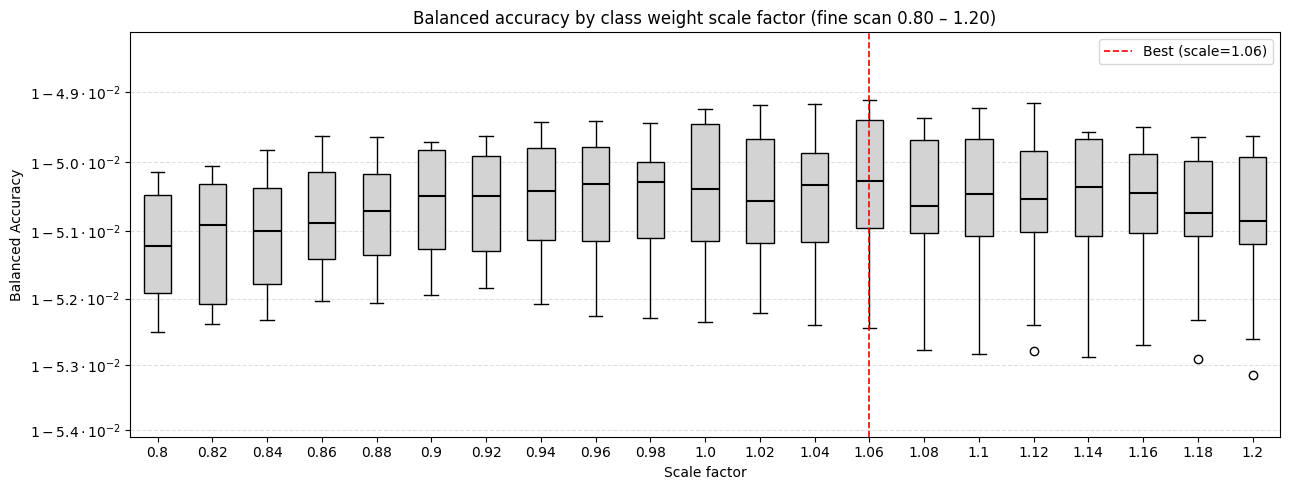

In [9]:
sorted_fine = sorted(fine_scores_df['scale_factor'].unique())
fine_plot_data = [fine_scores_df.loc[fine_scores_df['scale_factor'] == sf, 'balanced_accuracy'].values
                  for sf in sorted_fine]
fine_labels   = [str(sf) for sf in sorted_fine]
best_fine_idx = sorted_fine.index(best_scale_factor) + 1

plt.figure(figsize=(13, 5))
plt.boxplot(
    fine_plot_data,
    tick_labels=fine_labels,
    patch_artist=True,
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)
plt.axvline(x=best_fine_idx, color='red', linestyle='--', linewidth=1.2,
            label=f'Best (scale={best_scale_factor})')
plt.title('Balanced accuracy by class weight scale factor (fine scan 0.80 – 1.20)')
plt.xlabel('Scale factor')
plt.ylabel('Balanced Accuracy')
plt.yscale('logit')
all_vals = np.concatenate(fine_plot_data)
plt.ylim([max(0.01, all_vals.min() * 0.999), min(0.99, all_vals.max() * 1.001)])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 4. Performance estimation

Estimate balanced accuracy of the fully optimized model (winning hyperparameters + winning class weights) using the preprocessed CV folds.

In [10]:
%%time

if RUN_PERFORMANCE_ESTIMATION:

    fold_scores = []

    for i, fold in enumerate(cv_folds):
        print(f'Fold {i + 1} of {n_folds}...', end='\r')

        model = HistGradientBoostingClassifier(
            **winning_params,
            class_weight=best_class_weights,
            random_state=315
        )
        model.fit(fold['x_train'], fold['y_train'])

        y_pred = model.predict(fold['x_validation'])
        score  = balanced_accuracy_score(fold['y_validation'], y_pred)
        fold_scores.append(score)

    with open(PERFORMANCE_SCORES, 'wb') as f:
        pickle.dump(fold_scores, f)

    print()

else:
    with open(PERFORMANCE_SCORES, 'rb') as f:
        fold_scores = pickle.load(f)

ci_lower, ci_upper = np.percentile(fold_scores, [2.5, 97.5])

print(f'Median balanced accuracy: {np.median(fold_scores):.4f}')
print(f'Mean balanced accuracy:   {np.mean(fold_scores):.4f}')
print(f'95% confidence interval:  [{ci_lower:.4f}, {ci_upper:.4f}]')

Fold 10 of 10...
Median balanced accuracy: 0.9494
Mean balanced accuracy:   0.9493
95% confidence interval:  [0.9476, 0.9507]
CPU times: user 23min 55s, sys: 5.92 s, total: 24min 1s
Wall time: 2min 12s


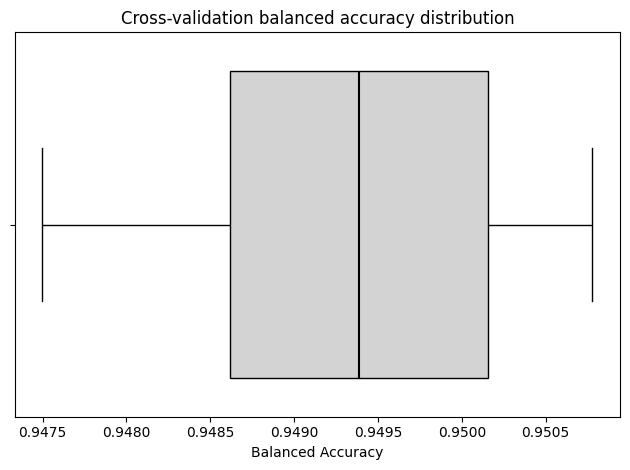

In [11]:
plt.title('Cross-validation balanced accuracy distribution')
sns.boxplot(
    x=fold_scores,
    color='lightgray',
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)
plt.xlabel('Balanced Accuracy')
plt.tight_layout()
plt.show()

## 5. Final model and submission

Retrain on the full preprocessed dataset (from notebook 03) using the optimized hyperparameters and class weights, then generate a competition submission.

In [12]:
# Load full preprocessed training and test datasets
train_df = pd.read_csv(FINAL_TRAINING_DATA)
test_df  = pd.read_csv(FINAL_TESTING_DATA)

print(f'Training data: {train_df.shape}')
print(f'Test data:     {test_df.shape}')

Training data: (690088, 33)
Test data:     (295753, 33)


In [13]:
model = HistGradientBoostingClassifier(
    **winning_params,
    class_weight=best_class_weights,
    random_state=315
)

model.fit(train_df.drop('health_condition', axis=1), train_df['health_condition'])

y_pred = model.predict(test_df.drop('id', axis=1))

submission_df = pd.DataFrame({
    'id': test_df['id'],
    'health_condition': label_encoder.inverse_transform(y_pred)
})

submission_df.to_csv('../data/submission.csv', index=False)

print(f'Submission saved ({len(submission_df)} rows)')
print(submission_df['health_condition'].value_counts())

Submission saved (295753 rows)
health_condition
at-risk      238763
unhealthy     35040
fit           21950
Name: count, dtype: int64
